# Sales Data Analysis & Interactive Dashboard

## VedGrow Internship | Task 2

### Project Overview

This project analyzes a retail sales dataset to uncover revenue trends, top-performing products, regional performance, and year-over-year growth. The analysis combines Python, Pandas, and Plotly to create an interactive dashboard that supports data-driven business decisions.

### Business Objective

Identify sales trends, high-performing categories, products, and regions while building an interactive dashboard for business reporting.

## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

## Load Dataset

The retail sales dataset is loaded into Pandas for exploration and analysis.

In [2]:
df = pd.read_csv("sales_data.csv", encoding="latin1")

## Data Preview

A quick look at the first five records helps verify that the dataset has been imported correctly.

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Overview and Cleaning

This section examines the dataset's structure, data types, missing values, and duplicate records before preparing it for analysis.

In [4]:
df.shape

(9994, 21)

In [5]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [14]:
df["Revenue"] = df["Sales"]

## Monthly Revenue Trend

This visualization tracks revenue over time to identify seasonal patterns and monthly sales performance.

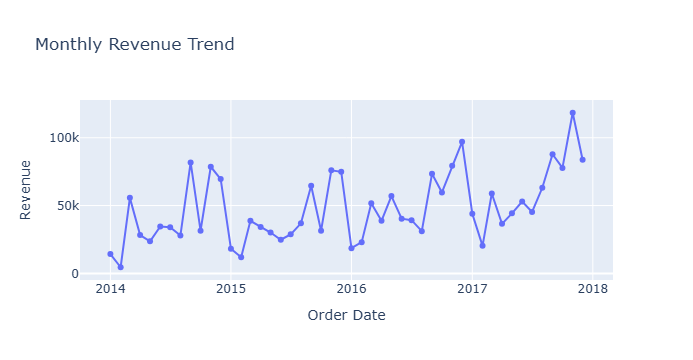

In [15]:
monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

fig = px.line(
    monthly_sales,
    x="Order Date",
    y="Revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.show()

## Revenue by Category

This chart compares total revenue generated by each product category.

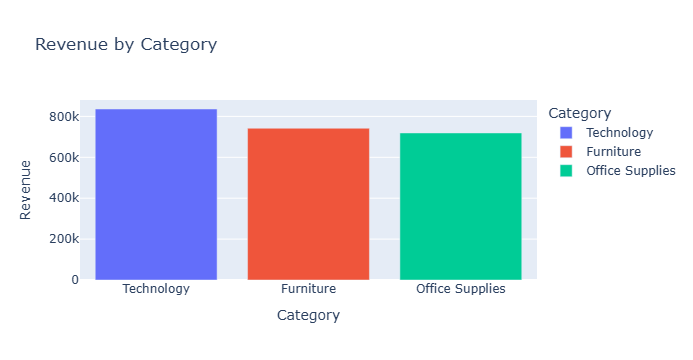

In [16]:
category_sales = (
    df.groupby("Category")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Revenue", ascending=False)
)

fig = px.bar(
    category_sales,
    x="Category",
    y="Revenue",
    color="Category",
    title="Revenue by Category"
)

fig.show()

## Top 10 Products by Revenue

The highest revenue-generating products are identified to understand which products contribute most to overall sales.

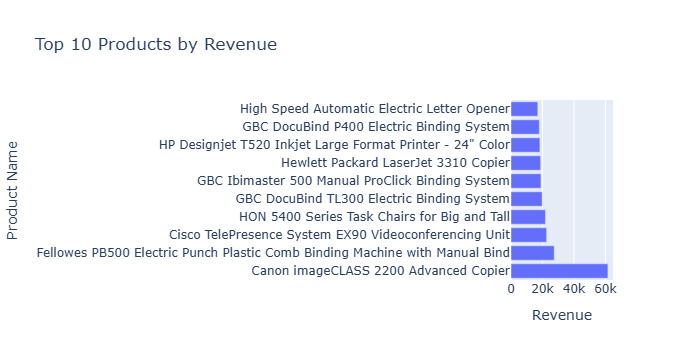

In [17]:
top_products = (
    df.groupby("Product Name")["Revenue"]
      .sum()
      .nlargest(10)
      .reset_index()
)

fig = px.bar(
    top_products,
    x="Revenue",
    y="Product Name",
    orientation="h",
    title="Top 10 Products by Revenue"
)

fig.show()

## Top Regions by Revenue

This analysis compares revenue across different regions to highlight the strongest-performing markets.

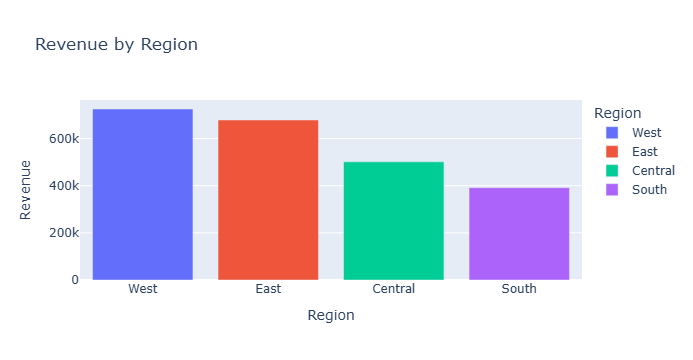

In [18]:
top_regions = (
    df.groupby("Region")["Revenue"]
      .sum()
      .reset_index()
      .sort_values("Revenue", ascending=False)
)

fig = px.bar(
    top_regions,
    x="Region",
    y="Revenue",
    color="Region",
    title="Revenue by Region"
)

fig.show()

## Yearly Revenue Analysis

Revenue is aggregated by year to observe long-term business growth.

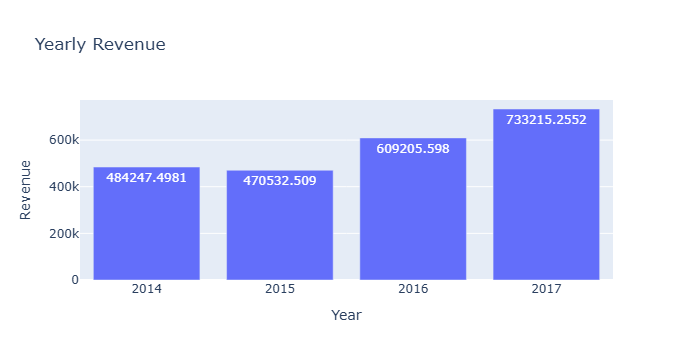

In [19]:
yearly_sales = (
    df.groupby(df["Order Date"].dt.year)["Revenue"]
      .sum()
      .reset_index()
)

yearly_sales.columns = ["Year", "Revenue"]

fig = px.bar(
    yearly_sales,
    x="Year",
    y="Revenue",
    text="Revenue",
    title="Yearly Revenue"
)

fig.show()

## Year-over-Year Growth

Year-over-year growth measures how revenue changes from one year to the next, helping evaluate business performance over time.

In [20]:
yearly_sales["YoY Growth %"] = yearly_sales["Revenue"].pct_change() * 100

yearly_sales

,Year,Revenue,YoY Growth %
0,2014,484247.4981,NaN
1,2015,470532.5090,-2.832227
2,2016,609205.5980,29.471521
3,2017,733215.2552,20.355962


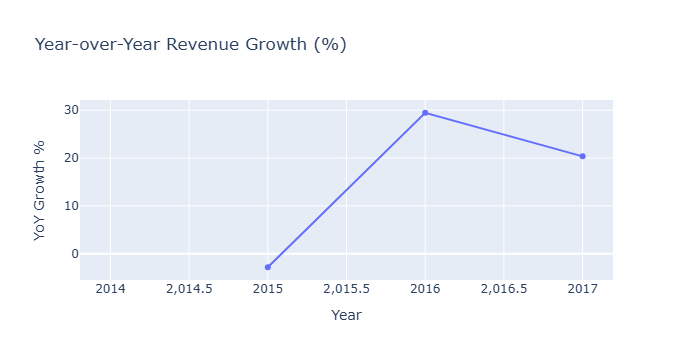

In [21]:
fig = px.line(
    yearly_sales,
    x="Year",
    y="YoY Growth %",
    markers=True,
    title="Year-over-Year Revenue Growth (%)"
)

fig.show()

## Business KPI Summary

Key business metrics provide a quick overview of overall performance.

In [22]:
total_revenue = df["Revenue"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")

Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793


## Interactive Sales Dashboard

This dashboard combines multiple interactive Plotly visualizations into a single business reporting view.

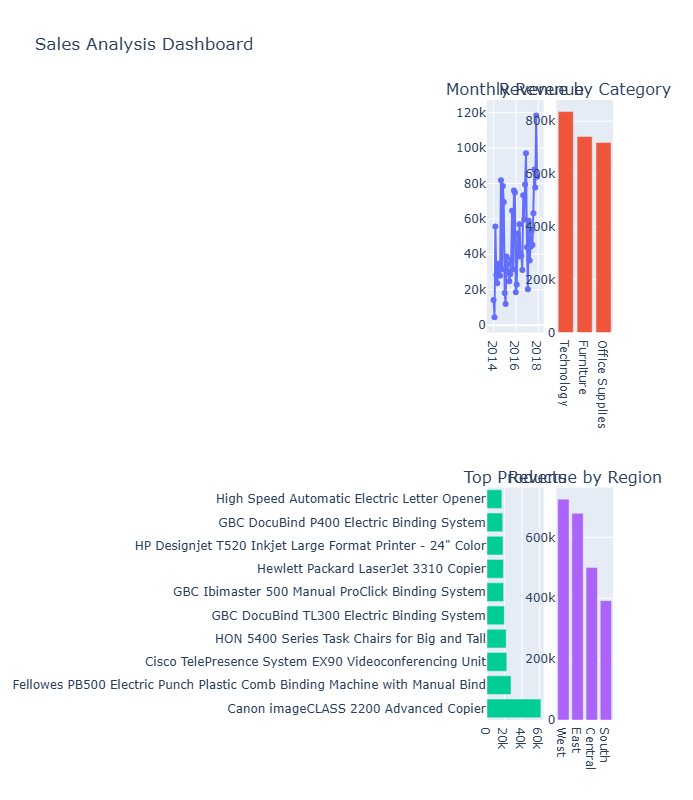

In [23]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Monthly Revenue",
        "Revenue by Category",
        "Top Products",
        "Revenue by Region"
    )
)

fig.add_trace(
    go.Scatter(
        x=monthly_sales["Order Date"],
        y=monthly_sales["Revenue"],
        mode="lines+markers",
        name="Monthly Revenue"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=category_sales["Category"],
        y=category_sales["Revenue"],
        name="Category"
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Bar(
        x=top_products["Revenue"],
        y=top_products["Product Name"],
        orientation="h",
        name="Products"
    ),
    row=2,
    col=1
)

fig.add_trace(
    go.Bar(
        x=top_regions["Region"],
        y=top_regions["Revenue"],
        name="Region"
    ),
    row=2,
    col=2
)

fig.update_layout(
    title="Sales Analysis Dashboard",
    height=800,
    showlegend=False
)

fig.show()

## Key Insights

### **Insight 1: Technology Generated the Highest Revenue**

The Technology category generated the highest overall revenue, making it the strongest-performing product category. This indicates that technology products were the primary contributors to the company's sales performance.

### **Insight 2: Revenue Showed Consistent Growth Over Time**

The yearly revenue analysis revealed an overall upward trend in sales across the available years. This suggests that the business experienced steady growth, with positive year-over-year improvements in revenue.

### **Insight 3: A Small Number of Products Drove Significant Revenue**

The Top 10 Products analysis showed that a limited number of products contributed a substantial portion of total revenue. This highlights the importance of high-performing products in driving overall business success.

### **Insight 4: Regional Performance Varied**

Revenue differed across regions, with some regions consistently outperforming others. This suggests that customer demand and sales performance were not evenly distributed across all markets.

### **Insight 5: Revenue Was Unevenly Distributed**

The revenue distribution was heavily right-skewed, meaning most transactions were relatively small while a few large sales contributed significantly to total revenue. This indicates that high-value orders played an important role in overall revenue generation.

## Conclusion

This project demonstrates how Python, Pandas, and Plotly can be used to clean data, perform business-focused sales analysis, and build an interactive dashboard. The findings provide valuable insights into revenue trends, product performance, regional sales, and business growth, supporting more informed decision-making.